In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

In [4]:
ar = pd.read_csv(Path('data/ar.csv'))
book_sales = pd.read_csv(Path('data/book_sales.csv'))
# ar
book_sales.shape

(30, 3)

In [6]:
book_sales['Time'] = np.arange(len(book_sales.index))
book_sales['Lag_1'] = book_sales.Hardcover.shift(1)
book_sales

,Date,Paperback,Hardcover,Time,Lag_1
0,2000-04-01,199,139,0,NaN
1,2000-04-02,172,128,1,139.0
2,2000-04-03,111,172,2,128.0
3,2000-04-04,209,139,3,172.0
4,2000-04-05,161,191,4,139.0
5,2000-04-06,119,168,5,191.0
6,2000-04-07,195,170,6,168.0
7,2000-04-08,195,145,7,170.0
8,2000-04-09,131,184,8,145.0
9,2000-04-10,183,135,9,184.0


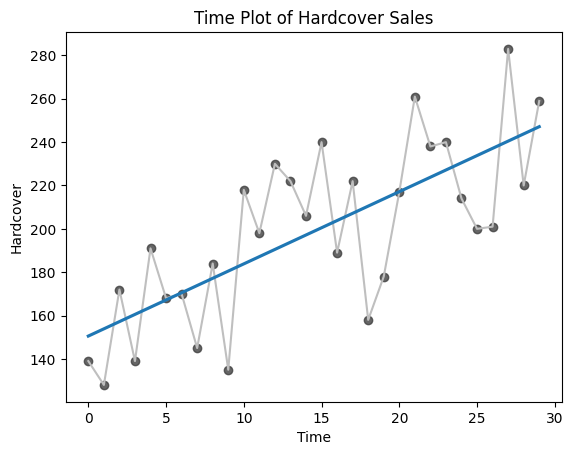

In [14]:
fix, ax = plt.subplots()
ax.plot('Time', 'Hardcover', data = book_sales, color = '0.75')
ax = sns.regplot(x = 'Time', y = 'Hardcover', data = book_sales, 
                 ci = None, scatter_kws=dict(color='0.25') )
ax.set_title('Time Plot of Hardcover Sales');


Text(0.5, 1.0, 'Series2')

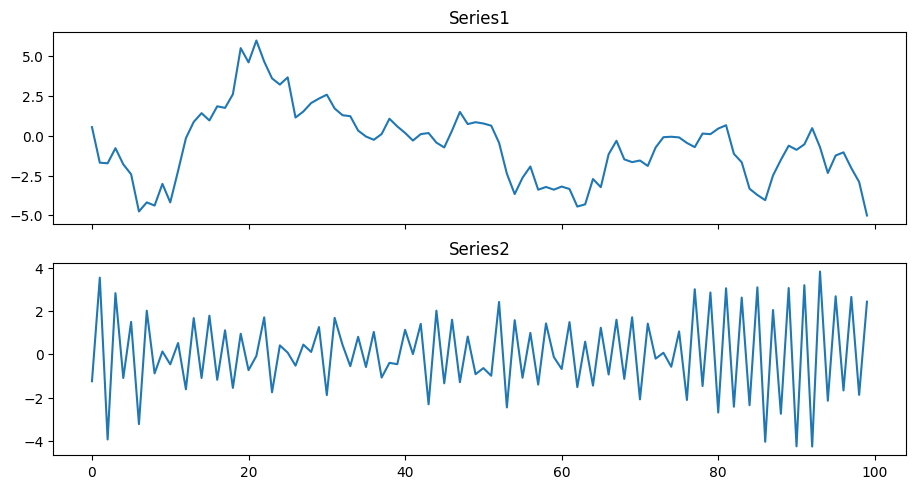

In [15]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 5.5), sharex=True)
ax1.plot(ar['ar1'])
ax1.set_title('Series1')

ax2.plot(ar['ar2'])
ax2.set_title('Series2')

In [20]:
### Linear regression model

dtype = {
    'store_nbr': 'category',
    'family': 'category',
    'sales': 'float32',
    'onpromotion': 'uint64',
}
store_sales = pd.read_csv('data/train.csv', dtype=dtype, 
                            parse_dates=['date'], infer_datetime_format=True)

C:\Users\15887\AppData\Local\Temp\ipykernel_22884\3622472201.py:9: FutureWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  store_sales = pd.read_csv('data/train.csv', dtype=dtype,


In [21]:
store_sales = store_sales.set_index('date').to_period('D')
store_sales = store_sales.set_index(['store_nbr', 'family'], append=True)
store_sales


id        sales  \
date       store_nbr family                                             
2013-01-01 1         AUTOMOTIVE                        0     0.000000   
                     BABY CARE                         1     0.000000   
                     BEAUTY                            2     0.000000   
                     BEVERAGES                         3     0.000000   
                     BOOKS                             4     0.000000   
...                                                  ...          ...   
2017-08-15 9         POULTRY                     3000883   438.132996   
                     PREPARED FOODS              3000884   154.552994   
                     PRODUCE                     3000885  2419.729004   
                     SCHOOL AND OFFICE SUPPLIES  3000886   121.000000   
                     SEAFOOD                     3000887    16.000000   

                                                 onpromotion  
date       store_nbr family                                   
2013-01-01 1         AUTOMOTIVE                            0  
                     BABY CARE                             0  
                     BEAUTY                                0  
                     BEVERAGES                             0  
                     BOOKS                                 0  
...                                                      ...  
2017-08-15 9         POULTRY                               0  
                     PREPARED FOODS                        1  
                     PRODUCE                             148  
                     SCHOOL AND OFFICE SUPPLIES            8  
                     SEAFOOD                               0  

[3000888 rows x 3 columns]

In [39]:
average_sales = store_sales.groupby('date').mean()['sales']
# average_sales
df = average_sales.to_frame()
# df.head()
df['time'] = np.arange(len(df.index))
X = df.loc[:, ['time']] # dataframe
y = df.loc[:,'sales'] # dataframe
model = LinearRegression()
model.fit(X, y)
y_pred = pd.Series(model.predict(X), index = X.index)
y_pred

date
2013-01-01    194.232790
2013-01-02    194.427137
2013-01-03    194.621484
2013-01-04    194.815831
2013-01-05    195.010178
                 ...    
2017-08-11    520.541320
2017-08-12    520.735667
2017-08-13    520.930014
2017-08-14    521.124361
2017-08-15    521.318708
Freq: D, Length: 1684, dtype: float64

,sales
date,
2013-01-01,1.409438
2013-01-02,278.390808
2013-01-03,202.840195
2013-01-04,198.911163
2013-01-05,267.873260


date
2013-01-01    194.232790
2013-01-02    194.427137
2013-01-03    194.621484
2013-01-04    194.815831
2013-01-05    195.010178
                 ...    
2017-08-11    520.541320
2017-08-12    520.735667
2017-08-13    520.930014
2017-08-14    521.124361
2017-08-15    521.318708
Freq: D, Length: 1684, dtype: float64

In [37]:
# Set Matplotlib defaults
# plt.style.use("seaborn-whitegrid")
sns.set_style("whitegrid")
plt.rc("figure", autolayout=True, figsize=(11, 4))
plt.rc(
    "axes",
    labelweight="bold",
    labelsize="large",
    titleweight="bold",
    titlesize=14,
    titlepad=10,
)
plot_params = dict(
    color="0.75",
    style=".-",
    markeredgecolor="0.25",
    markerfacecolor="0.25",
    legend=False,
)

Text(0.5, 1.0, 'Time Plot of Total Store Sales')

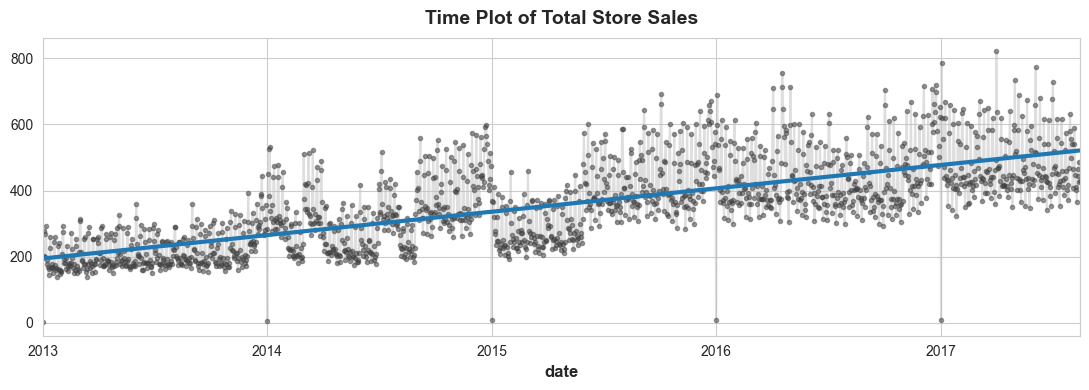

In [38]:
ax = y.plot(**plot_params,  alpha = 0.5)
ax = y_pred.plot(ax = ax, linewidth = 3)
ax.set_title('Time Plot of Total Store Sales')

In [42]:
df = average_sales.to_frame()

df['lag_1'] = df['sales'].shift(1)
X = df.loc[:, ['lag_1']].dropna()
y = df.loc[:, 'sales']
y, X = y.align(X, join = 'inner') ## Align both X, y  keep only common values drop different

model = LinearRegression()
model.fit(X, y)

y_pred = pd.Series(model.predict(X), index = X.index)
y_pred

date
2013-01-02     85.301689
2013-01-03    297.268250
2013-01-04    239.451340
2013-01-05    236.444550
2013-01-06    289.219421
                 ...    
2017-08-11    363.958893
2017-08-12    439.106384
2017-08-13    424.615509
2017-08-14    455.968994
2017-08-15    410.998535
Freq: D, Length: 1683, dtype: float32

[None,
 Text(0, 0.5, 'sales'),
 Text(0.5, 0, 'lag_1'),
 Text(0.5, 1.0, 'lag sales plot')]

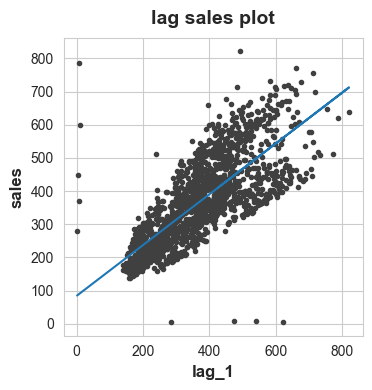

In [46]:
fig, ax = plt.subplots()
ax.plot(X['lag_1'], y, '.', color= '0.25' )
ax.plot(X['lag_1'], y_pred )
ax.set(aspect='equal', ylabel='sales', xlabel='lag_1',  title='lag sales plot')